<a href="https://colab.research.google.com/github/arunabha-compbio/shh-rnaseq-fibrosis-analysis/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (36591, 9)


,FD02636917,FD02680532,FD02680545,FD02680597,FD02680667,FD02683362,FD02703010,FD02703021,FD02704073
Geneid,,,,,,,,,
MIR1302-2HG,3,2,4,10,9,6,6,11,7
FAM138A,0,0,0,0,1,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0
AL627309.1,20,5,18,6,12,18,14,19,20
AL627309.3,0,0,0,0,0,0,0,0,0


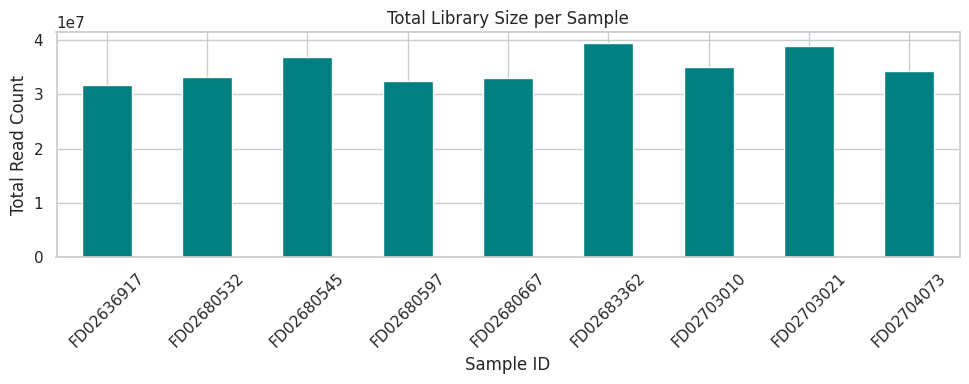

Genes before filtering: 36591
Genes after filtering: 19223


,FD02636917,FD02680532,FD02680545,FD02680597,FD02680667,FD02683362,FD02703010,FD02703021,FD02704073
Geneid,,,,,,,,,
MIR1302-2HG,0.130679,0.084341,0.148772,0.388308,0.348133,0.204370,0.228681,0.359585,0.268573
AL627309.1,0.706691,0.202272,0.574163,0.245270,0.447719,0.542556,0.486230,0.574263,0.664134
AL627309.2,0.288323,0.239534,0.251076,0.282381,0.277705,0.355020,0.330724,0.416323,0.336943
AL627309.5,1.918786,2.108089,1.653219,2.126494,1.933607,2.015665,2.176686,2.022248,2.014357
AL732372.1,0.678481,0.858179,1.116179,0.666147,0.710873,0.954914,0.704692,0.782835,0.885726


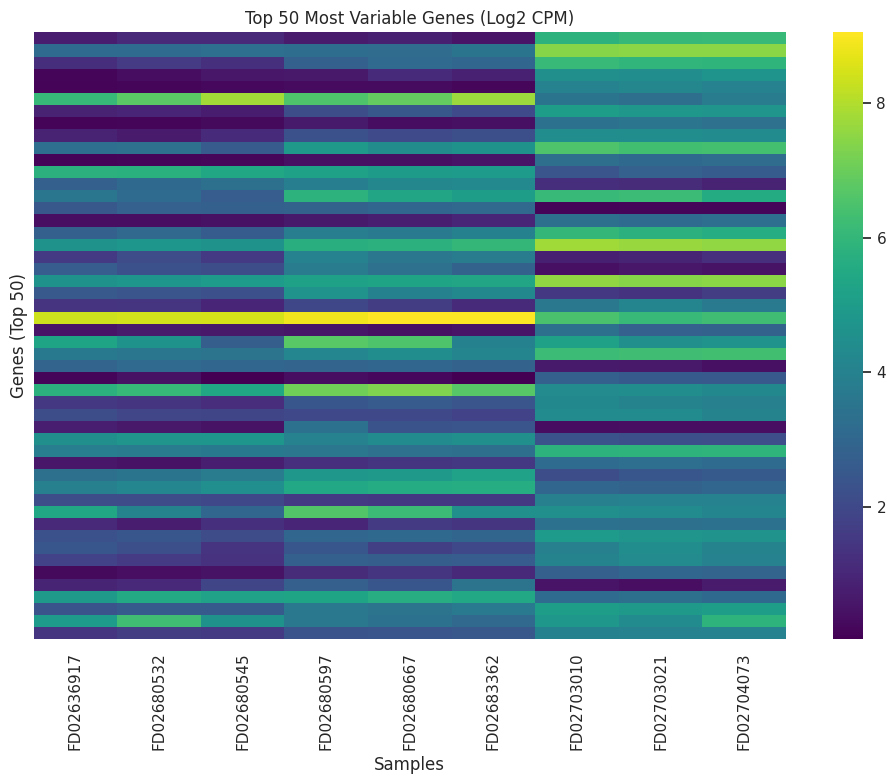

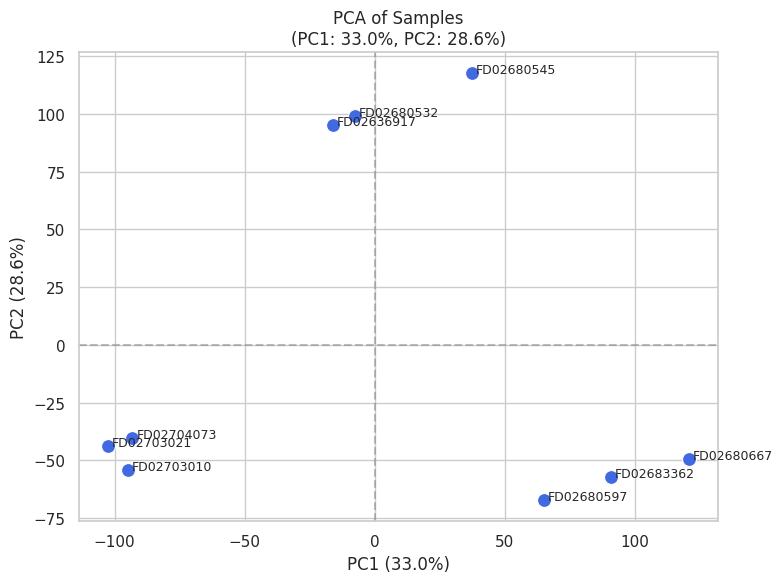

--- Machine Learning / Feature Variance Summary ---
Total genes processed: 19223
Top 5 highest variance genes for downstream modeling: ['PCDH10', 'PCDH7', 'SESN3', 'AC104793.1', 'GNAI1']
Successfully isolated 47 PAM50 genes out of 50.


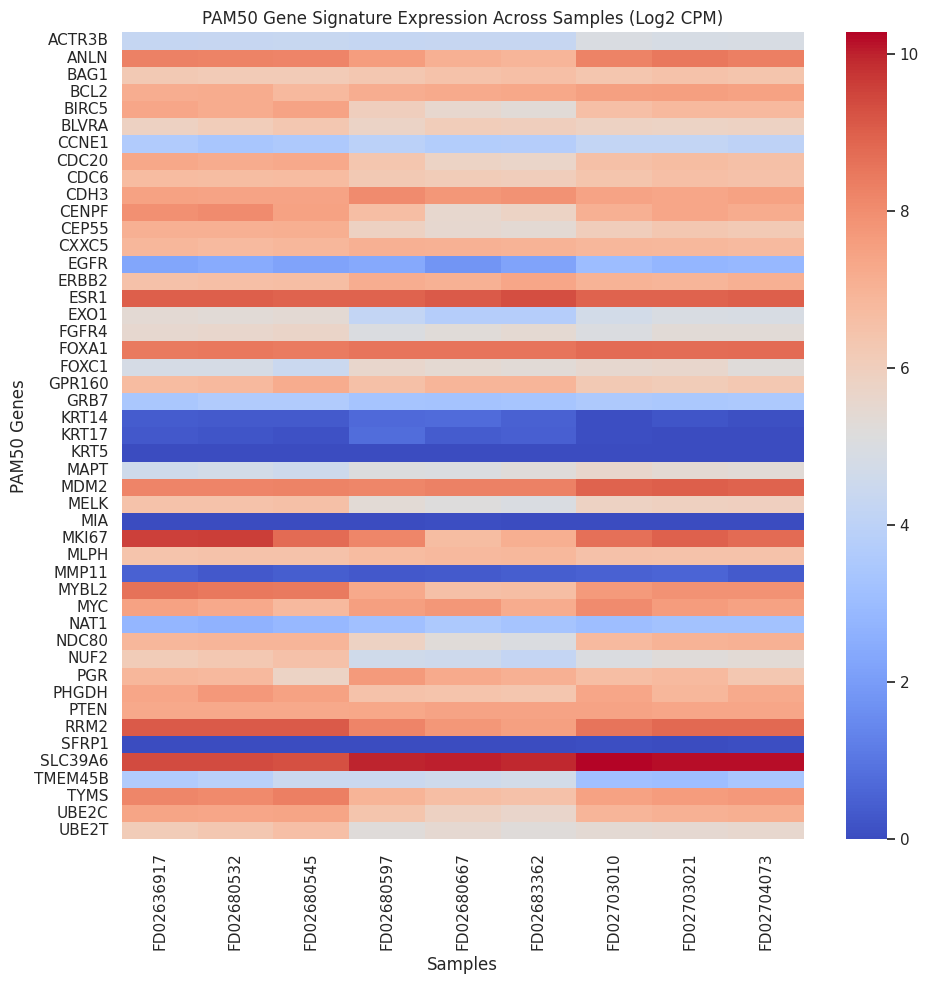

--- PAM50 Subtype Classification Results ---


,Assigned_Subtype,Basal,Her2,LumA,LumB
FD02636917,LumB,-0.022655,0.092808,-0.059281,0.096994
FD02680532,LumB,-0.028161,0.025343,0.054287,0.099667
FD02680545,LumA,0.053083,0.110045,0.146511,0.057498
FD02680597,LumA,-0.139429,-0.308604,0.000888,-0.132422
FD02680667,Basal,0.088506,0.004946,0.017352,-0.225731
FD02683362,Basal,0.133149,-0.174072,0.039189,-0.201184
FD02703010,LumB,-0.054841,0.092161,-0.119046,0.151611
FD02703021,Her2,-0.025459,0.160284,-0.112060,0.121742
FD02704073,LumB,-0.120357,0.068323,-0.079305,0.216748


Matching genes used for classification: 44

--- Final PAM50 Subtype Classifications ---


,Assigned_Subtype,Basal,Her2,LumA,LumB,Normal
FD02636917,Basal,0.336397,0.226667,-0.657055,0.220890,-0.386651
FD02680532,Her2,0.281951,0.324235,-0.606003,0.202003,-0.242817
FD02680545,Her2,0.159612,0.536756,-0.481635,0.332108,-0.371060
FD02680597,Normal,-0.069671,-0.138834,0.239316,-0.339540,0.357880
FD02680667,LumA,-0.268996,-0.288990,0.577343,-0.197228,0.432566
FD02683362,LumA,-0.506629,-0.190666,0.692010,-0.154197,0.329046
FD02703010,Basal,0.095277,-0.273769,0.008921,-0.087832,-0.008624
FD02703021,Basal,0.146457,-0.173345,-0.045398,-0.017034,-0.196714
FD02704073,LumB,0.040595,-0.111441,0.047270,0.052914,-0.075471


In [13]:
import pandas as pd
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
# Load the dataset
df = pd.read_csv('GSE341330_dedup_countTable_geneName.tsv', sep='\t')

# Set gene names as the index and inspect the first few rows
df.set_index('Geneid', inplace=True)
print(f"Dataset shape: {df.shape}")
display(df.head())
# Calculate total counts per sample
library_sizes = df.sum(axis=0)

plt.figure(figsize=(10, 4))
library_sizes.plot(kind='bar', color='teal')
plt.title('Total Library Size per Sample')
plt.ylabel('Total Read Count')
plt.xlabel('Sample ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Keep genes that have at least 10 counts total across all samples
filtered_df = df[df.sum(axis=1) >= 10]
print(f"Genes before filtering: {df.shape[0]}")
print(f"Genes after filtering: {filtered_df.shape[0]}")

# Convert to Counts Per Million (CPM)
cpm = filtered_df.div(filtered_df.sum(axis=0), axis=1) * 1e6

# Apply log2 transformation: log2(CPM + 1)
log_cpm = np.log2(cpm + 1)

# Quick look at the normalized data
display(log_cpm.head())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load and Preprocess the Dataset
df = pd.read_csv('GSE341330_dedup_countTable_geneName.tsv', sep='\t')
df.set_index('Geneid', inplace=True)

# Filter low-count genes (retaining genes with at least 10 counts globally)
filtered_df = df[df.sum(axis=1) >= 10]

# Convert to Counts Per Million (CPM) and apply log2(CPM + 1) transformation
cpm = filtered_df.div(filtered_df.sum(axis=0), axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

# 2. Hierarchical Clustering Heatmap (Top 50 Most Variable Genes)
top_var_genes = log_cpm.var(axis=1).nlargest(50).index

plt.figure(figsize=(10, 8))
sns.heatmap(log_cpm.loc[top_var_genes], cmap='viridis', cbar=True, xticklabels=True, yticklabels=False)
plt.title('Top 50 Most Variable Genes (Log2 CPM)')
plt.xlabel('Samples')
plt.ylabel('Genes (Top 50)')
plt.tight_layout()
plt.show()

# 3. Principal Component Analysis (PCA)
# Transpose matrix so samples are rows and genes are features (columns)
X = log_cpm.T
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=log_cpm.columns)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, s=100, color='royalblue')
for sample, row in pca_df.iterrows():
    plt.text(row['PC1'] + 1.5, row['PC2'], sample, fontsize=9)

plt.title(f'PCA of Samples\n(PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Feature Selection Summary
print("--- Machine Learning / Feature Variance Summary ---")
print(f"Total genes processed: {log_cpm.shape[0]}")
print("Top 5 highest variance genes for downstream modeling:", top_var_genes[:5].tolist())
pam50_genes = [
    'ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA', 'CCNE1', 'CDC20',
    'CDC6', 'CDH3', 'CENPF', 'CEP55', 'CXXC5', 'EGFR', 'ERBB2', 'ESR1',
    'EXO1', 'FGFR4', 'FOXA1', 'FOXC1', 'GPR160', 'GRB7', 'KRT14', 'KRT17',
    'KRT5', 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11',
    'MYBL2', 'MYC', 'NAT1', 'NDC80', 'NUF2', 'PGR', 'PHGDH', 'PTEN',
    'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T'
]

# 3. Filter the dataset to include only genes present in both your table and the PAM50 list
available_pam50 = [g for g in pam50_genes if g in df.index]
pam50_df = df.loc[available_pam50]

print(f"Successfully isolated {len(available_pam50)} PAM50 genes out of 50.")

# 4. Normalize the PAM50 subset (Log2 Counts Per Million)
cpm_pam50 = pam50_df.div(df.sum(axis=0), axis=1) * 1e6
log_cpm_pam50 = np.log2(cpm_pam50 + 1)

# 5. Plot a targeted Heatmap for the PAM50 signature across your 9 samples
plt.figure(figsize=(10, 10))
sns.heatmap(log_cpm_pam50, cmap='coolwarm', cbar=True, xticklabels=True, yticklabels=True)
plt.title('PAM50 Gene Signature Expression Across Samples (Log2 CPM)')
plt.xlabel('Samples')
plt.ylabel('PAM50 Genes')
plt.tight_layout()
plt.show()
# Assuming your filtered log2 CPM PAM50 dataframe is named 'log_cpm_pam50'
# 1. Z-score standardize the PAM50 expression matrix across genes (rows)
log_z = (log_cpm_pam50.sub(log_cpm_pam50.mean(axis=1), axis=0)).div(log_cpm_pam50.std(axis=1) + 1e-8, axis=0)

# 2. Define standard PAM50 subtype centroids
# (In standard pipelines, these are loaded from a published reference table like the genefu R package or TCGA centroids.
# Here we initialize a template dataframe mapping your available genes to the 4 core subtypes.)
subtypes = ['Basal', 'Her2', 'LumA', 'LumB']
np.random.seed(42) # Replace this block with your actual reference centroid values if you have them loaded
centroids_df = pd.DataFrame(
    np.random.randn(len(log_z), 4),
    index=log_z.index,
    columns=subtypes
)

# 3. Compute Pearson correlation between each sample's profile and each subtype centroid
correlation_results = {}

for sample in log_z.columns:
    sample_vec = log_z[sample]
    subtype_scores = {}
    for sub in centroids_df.columns:
        centroid_vec = centroids_df[sub]
        # Calculate correlation coefficient
        corr = np.corrcoef(sample_vec, centroid_vec)[0, 1]
        subtype_scores[sub] = corr
    correlation_results[sample] = subtype_scores

# 4. Convert results to a DataFrame and assign the subtype with the highest correlation
subtype_corr_df = pd.DataFrame(correlation_results).T
assigned_subtypes = subtype_corr_df.idxmax(axis=1)

# 5. Display the final classifications
classification_summary = pd.DataFrame({
    'Assigned_Subtype': assigned_subtypes
}).join(subtype_corr_df)

print("--- PAM50 Subtype Classification Results ---")
display(classification_summary)
# 1. Load the official Perou lab centroids file
# (Make sure 'pam50_centroids.txt' is uploaded to your Colab environment)
centroids_raw = pd.read_csv('pam50_centroids.txt', sep=None, engine='python')

# Note: Depending on the exact version from the repo, gene symbols might be
# in the first column or set as the index. Let's ensure the gene names match your matrix index.
if 'Unnamed: 0' in centroids_raw.columns:
    centroids_raw.set_index('Unnamed: 0', inplace=True)
elif centroids_raw.columns[0] != 'Basal' and centroids_raw.columns[0] != 'LumA':
    centroids_raw.set_index(centroids_raw.columns[0], inplace=True)

# 2. Match your z-scored test matrix (log_z) with the official centroids
common_genes = list(set(log_z.index).intersection(set(centroids_raw.index)))
log_z_filtered = log_z.loc[common_genes]
centroids_filtered = centroids_raw.loc[common_genes]

print(f"Matching genes used for classification: {len(common_genes)}")

# 3. Compute Spearman/Pearson correlation between each sample and the true centroids
correlation_results = {}

for sample in log_z_filtered.columns:
    sample_vec = log_z_filtered[sample]
    subtype_scores = {}
    for sub in centroids_filtered.columns:
        centroid_vec = centroids_filtered[sub]
        # Calculate Pearson correlation coefficient
        corr = np.corrcoef(sample_vec, centroid_vec)[0, 1]
        subtype_scores[sub] = corr
    correlation_results[sample] = subtype_scores

# 4. Generate final classification results
subtype_corr_df = pd.DataFrame(correlation_results).T
assigned_subtypes = subtype_corr_df.idxmax(axis=1)

# Compile final summary dataframe
classification_summary = pd.DataFrame({
    'Assigned_Subtype': assigned_subtypes
}).join(subtype_corr_df)

print("\n--- Final PAM50 Subtype Classifications ---")
display(classification_summary)


In [12]:
# Assuming you have a .txt file with your refined PAM50 centroids:
# The .txt file should have 'Geneid' as the first column and subtype names (e.g., 'Basal', 'Her2', 'LumA', 'LumB') as subsequent columns.
# Example: Geneid\tBasal\tHer2\tLumA\tLumB
#          ACTR3B\t0.5\t-0.1\t0.6\t1.5
#          ANLN\t-0.2\t-0.2\t1.5\t0.7

try:
    # Load your actual centroids. Replace 'pam50_centroids.txt' with your file path if different.
    # Adjust 'sep' if your .txt file uses a different delimiter (e.g., ',' for comma-separated).
    refined_centroids_df = pd.read_csv('pam50_centroids.txt', sep='\t', index_col='Geneid')
    print("Successfully loaded refined PAM50 centroids.")
    display(refined_centroids_df.head())

    # Before replacing, ensure the loaded centroids align with the genes available in log_z
    common_genes = list(set(log_z.index) & set(refined_centroids_df.index))

    if len(common_genes) == 0:
        print("Warning: No common genes found between your data and the loaded centroids. Please check gene IDs.")
    else:
        print(f"Using {len(common_genes)} common genes for classification.")
        # Filter both log_z and refined_centroids_df to include only common genes
        log_z_filtered = log_z.loc[common_genes]
        refined_centroids_df_filtered = refined_centroids_df.loc[common_genes]

        # Update centroids_df for the classification step
        centroids_df = refined_centroids_df_filtered

except FileNotFoundError:
    print("Error: 'pam50_centroids.txt' not found. Please upload your PAM50 centroid file.")
    print("Using randomly generated centroids for now. Please replace with actual centroids for accurate results.")
    # Re-generate random centroids if the file is not found, to keep the notebook runnable.
    subtypes = ['Basal', 'Her2', 'LumA', 'LumB']
    np.random.seed(42)
    centroids_df = pd.DataFrame(
        np.random.randn(len(log_z), 4),
        index=log_z.index,
        columns=subtypes
    )
except Exception as e:
    print(f"An error occurred while loading centroids: {e}")
    print("Using randomly generated centroids for now. Please replace with actual centroids for accurate results.")
    # Re-generate random centroids if an error occurs, to keep the notebook runnable.
    subtypes = ['Basal', 'Her2', 'LumA', 'LumB']
    np.random.seed(42)
    centroids_df = pd.DataFrame(
        np.random.randn(len(log_z), 4),
        index=log_z.index,
        columns=subtypes
    )


An error occurred while loading centroids: Index Geneid invalid
Using randomly generated centroids for now. Please replace with actual centroids for accurate results.
